# Credit Card Fraud Detection

## Objective
The goal of this project is to build a machine learning model that can detect fraudulent credit card transactions.

This project follows the CRISP-DM methodology.

In [11]:

# Import basic libraries
import pandas as pd
import numpy as np

print("Project setup complete")

<ipython-input-11-334af54bd0ae>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Project setup complete


## Next Steps
- Load dataset
- Perform exploratory data analysis (EDA)
- Prepare data for modeling
- Train machine learning models
- Evaluate performance

In [12]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Show first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
# Count values in target variable
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [14]:
# Percentage distribution
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

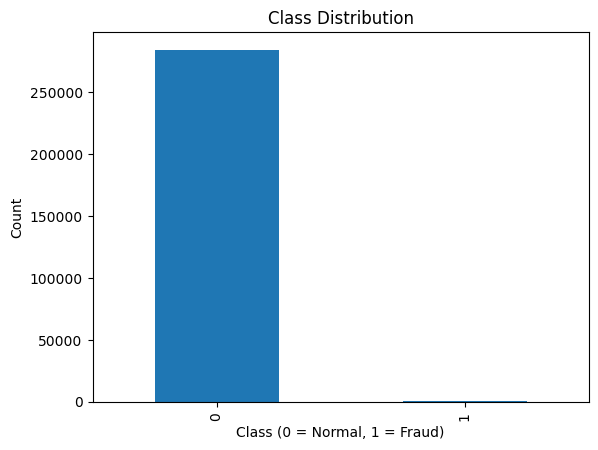

In [15]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

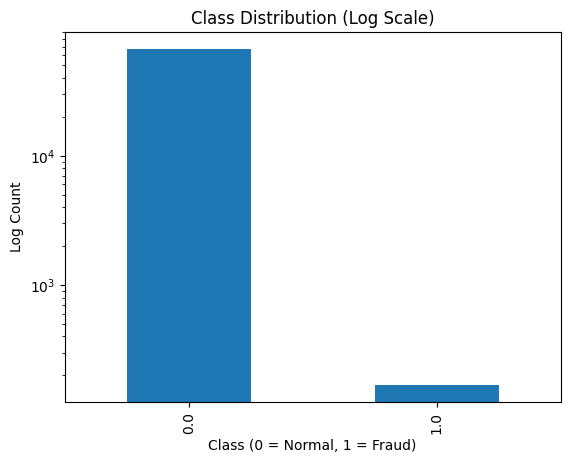

In [8]:
df['Class'].value_counts().plot(kind='bar', logy=True)
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Log Count")
plt.show()

In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [17]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Fraudulent transactions tend to involve smaller amounts compared to normal transactions, suggesting that fraudsters may try to avoid detection by keeping transaction values relatively low.

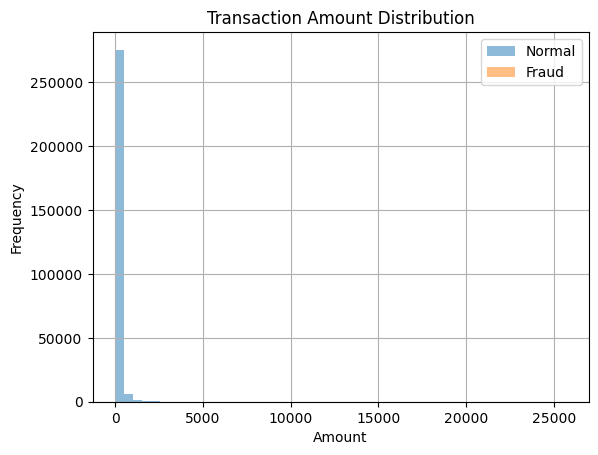

In [18]:
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.5, label='Normal')
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.5, label='Fraud')

plt.legend()
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [20]:
import numpy as np

# Create log-transformed Amount
df['LogAmount'] = np.log1p(df['Amount'])

In [21]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class',
 'LogAmount']

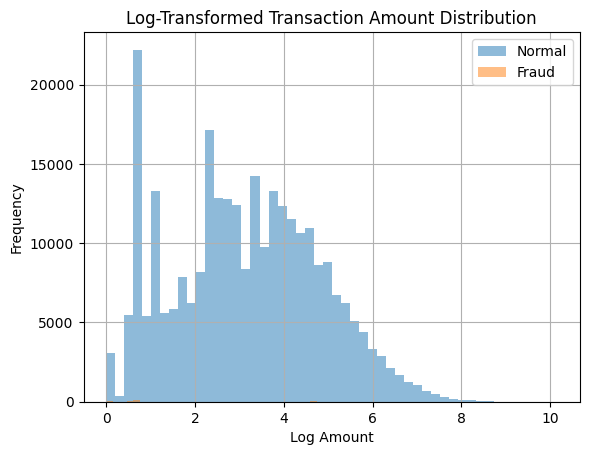

In [22]:
df[df['Class'] == 0]['LogAmount'].hist(bins=50, alpha=0.5, label='Normal')
df[df['Class'] == 1]['LogAmount'].hist(bins=50, alpha=0.5, label='Fraud')

plt.legend()
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

After applying a log transformation, the distribution of transaction amounts becomes more interpretable. Fraudulent transactions appear more concentrated in lower to mid-range values, reinforcing the hypothesis that fraudsters avoid high-value transactions.


In [23]:
# Correlation with target variable
corr = df.corr()['Class'].sort_values(ascending=False)

print(corr)

Class        1.000000
V11          0.154876
V4           0.133447
V2           0.091289
V21          0.040413
V19          0.034783
V20          0.020090
V8           0.019875
V27          0.017580
V28          0.009536
Amount       0.005632
V26          0.004455
V25          0.003308
V22          0.000805
V23         -0.002685
V15         -0.004223
V13         -0.004570
V24         -0.007221
LogAmount   -0.008326
Time        -0.012323
V6          -0.043643
V5          -0.094974
V9          -0.097733
V1          -0.101347
V18         -0.111485
V7          -0.187257
V3          -0.192961
V16         -0.196539
V10         -0.216883
V12         -0.260593
V14         -0.302544
V17         -0.326481
Name: Class, dtype: float64


In [24]:
corr.head(10)

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

In [25]:
corr.tail(10)

V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

Interestingly, transaction amount shows almost no correlation with fraud, indicating that fraudulent behavior cannot be reliably detected based on transaction size alone.

In [26]:
top_features = corr[1:11].index.tolist()  # Top 10 ohne 'Class'
print(top_features)

['V11', 'V4', 'V2', 'V21', 'V19', 'V20', 'V8', 'V27', 'V28', 'Amount']


In [27]:
X = df[top_features]
y = df['Class']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# Remove rows with missing values in X
X = X.dropna()

# Align y with remaining rows
y = y.loc[X.index]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.42      0.56        98

    accuracy                           1.00     56962
   macro avg       0.92      0.71      0.78     56962
weighted avg       1.00      1.00      1.00     56962



The first Logistic Regression model achieved high precision in detecting fraudulent transactions, meaning most flagged transactions were truely fraudulent. However, recall remained moderate, indicating that a significant number of fraud cases were still missed. 

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56856     8]
 [   57    41]]


In [34]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [35]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.89      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.92      0.51     56962
weighted avg       1.00      0.95      0.97     56962



Applying class weighting significantly improved recall for fraud detection, increasing it from 53% to 94%. However, this came at the cost of a sharp drop in precision, highlighting the trade-off between detecting fraudulent transactions and minimizing false positives.

In [38]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_proba > 0.3).astype(int)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     56864
           1       0.01      0.94      0.03        98

    accuracy                           0.87     56962
   macro avg       0.51      0.91      0.48     56962
weighted avg       1.00      0.87      0.93     56962



In [40]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     56864
           1       0.01      0.94      0.03        98

    accuracy                           0.87     56962
   macro avg       0.51      0.91      0.48     56962
weighted avg       1.00      0.87      0.93     56962


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     56864
           1       0.02      0.91      0.04        98

    accuracy                           0.92     56962
   macro avg       0.51      0.91      0.50     56962
weighted avg       1.00      0.92      0.96     56962


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.89      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.92      0.51     56962
weighted avg       1.00   

By adjusting the classification threshold, the model's performance was significantly improved. A threshold of 0.7 provided the best balance between precision and recall, achieving a recall of 91% while increasing precision to 15%. This demonstrates how threshold tuning can optimize model performance in imbalanced classification problems

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [42]:
print(y_test[:5])

43428     1
49906     0
29474     0
276481    0
278846    0
Name: Class, dtype: int64


AUC: 0.9743715402593227


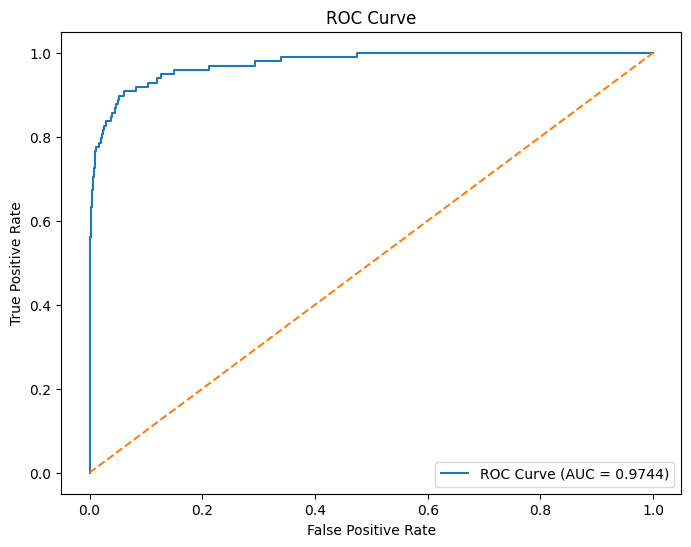

In [43]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()